In [3]:
import re
import pandas as pd

pattern = r'(\d{2})/(\w{3})/(\d{4}):(\d{2}):(\d{2}):(\d{2})'
data = []

with open(r'C:\Users\user\OG log_analysis\browse\browse', 'r') as file:
    for line in file:
        line = line.strip()
        match = re.match(pattern, line)
        if match:
            data.append({
                'day'  : match.group(1),
                'month': match.group(2),
                'year' : match.group(3),
                'hour' : int(match.group(4)),
                'event': 'browse'
            })

df = pd.DataFrame(data)
hourly = df.groupby('hour').size().reset_index(name='count')
print(hourly)

    hour   count
0      1  455226
1      2  432108
2      3  405827
3      4  381387
4      5  381942
5      6  401400
6      7  429128
7      8  464727
8      9  490788
9     10  511244
10    11  541543
11    12  483523


In [8]:
# Read product file
with open(r'C:\Users\user\OG log_analysis\browse\product', 'r') as file:
    for line in file:
        line = line.strip()
        match = re.match(pattern, line)
        if match:
            data.append({
                'day'  : match.group(1),
                'month': match.group(2),
                'year' : match.group(3),
                'hour' : int(match.group(4)),
                'event': 'product'
            })

# Read basket file
with open(r'C:\Users\user\OG log_analysis\browse\basket', 'r') as file:
    for line in file:
        line = line.strip()
        match = re.match(pattern, line)
        if match:
            data.append({
                'day'  : match.group(1),
                'month': match.group(2),
                'year' : match.group(3),
                'hour' : int(match.group(4)),
                'event': 'basket'
            })

# Rebuild DataFrame with all 3 events
df = pd.DataFrame(data)
hourly = df.groupby(['hour', 'event']).size().reset_index(name='count')
print(hourly)

    hour    event    count
0      1   basket    62104
1      1   browse   455226
2      1  product  1038872
3      2   basket    55104
4      2   browse   432108
5      2  product  1060188
6      3   basket    47080
7      3   browse   405827
8      3  product  1095676
9      4   basket    44920
10     4   browse   381387
11     4  product  1241244
12     5   basket    38440
13     5   browse   381942
14     5  product  1179640
15     6   basket    33312
16     6   browse   401400
17     6  product  1293404
18     7   basket    33684
19     7   browse   429128
20     7  product  1162952
21     8   basket    60424
22     8   browse   464727
23     8  product  1182644
24     9   basket    63332
25     9   browse   490788
26     9  product  1182436
27    10   basket    62334
28    10   browse   511244
29    10  product  1035928
30    11   basket    66526
31    11   browse   541543
32    11  product  1221096
33    12   basket    65066
34    12   browse   483523
35    12  product  1085688


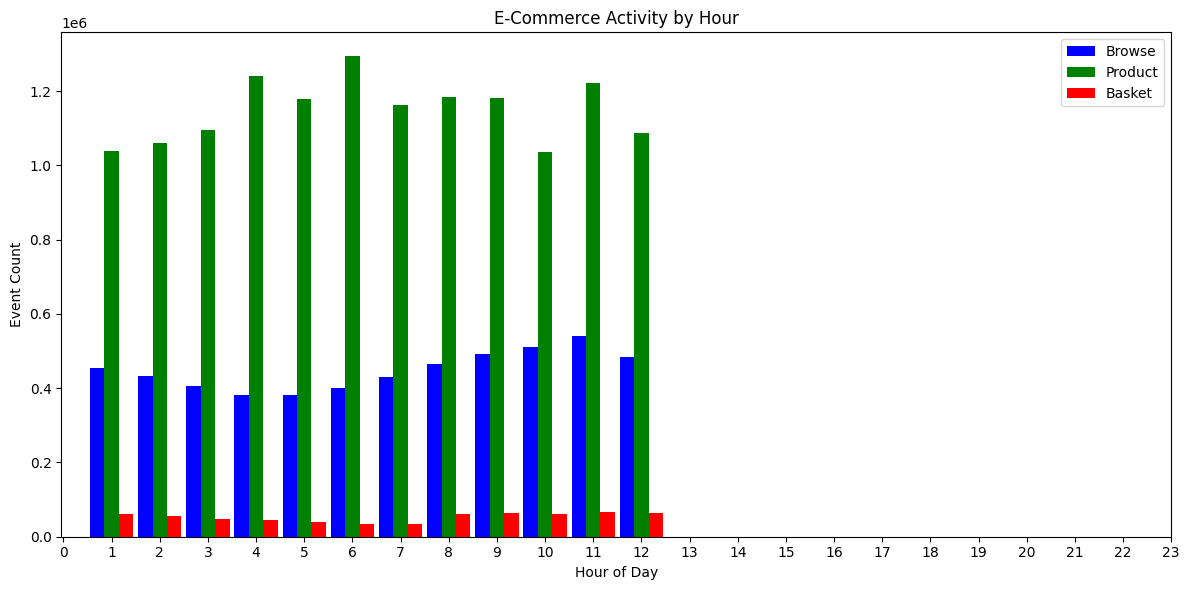

In [9]:
import matplotlib.pyplot as plt

# Separate each event
browse_data  = hourly[hourly['event'] == 'browse']
product_data = hourly[hourly['event'] == 'product']
basket_data  = hourly[hourly['event'] == 'basket']

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(browse_data['hour'] - 0.3,  browse_data['count'],  width=0.3, label='Browse',  color='blue')
plt.bar(product_data['hour'],        product_data['count'], width=0.3, label='Product', color='green')
plt.bar(basket_data['hour'] + 0.3,  basket_data['count'],  width=0.3, label='Basket',  color='red')

plt.title('E-Commerce Activity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Event Count')
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

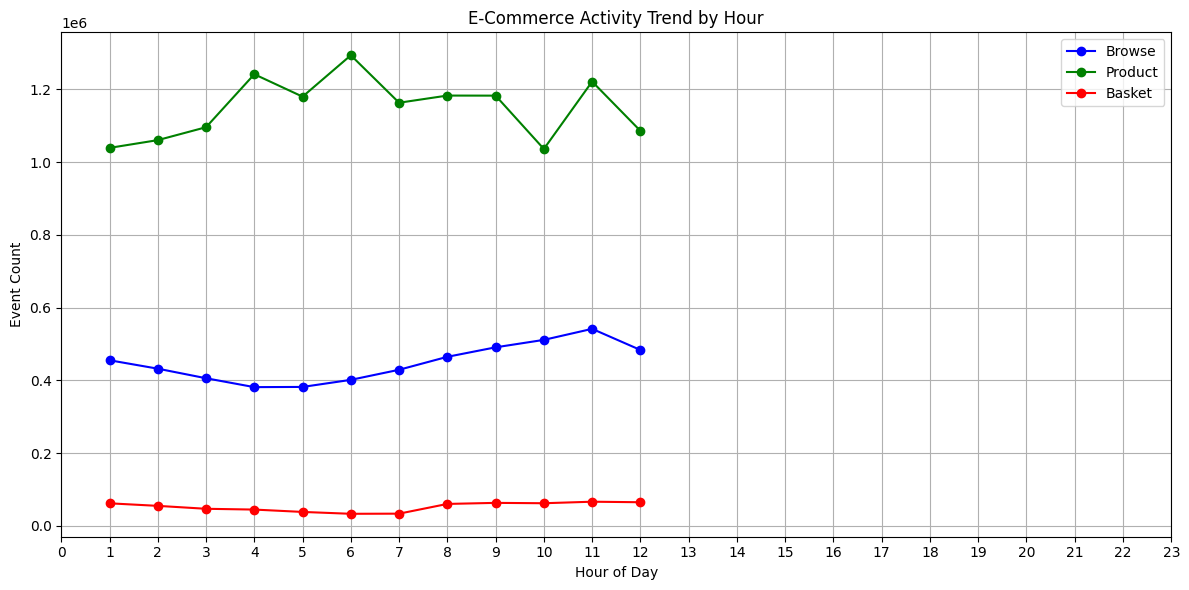

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(browse_data['hour'],  browse_data['count'],  marker='o', label='Browse',  color='blue')
plt.plot(product_data['hour'], product_data['count'], marker='o', label='Product', color='green')
plt.plot(basket_data['hour'],  basket_data['count'],  marker='o', label='Basket',  color='red')

plt.title('E-Commerce Activity Trend by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Event Count')
plt.legend()
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

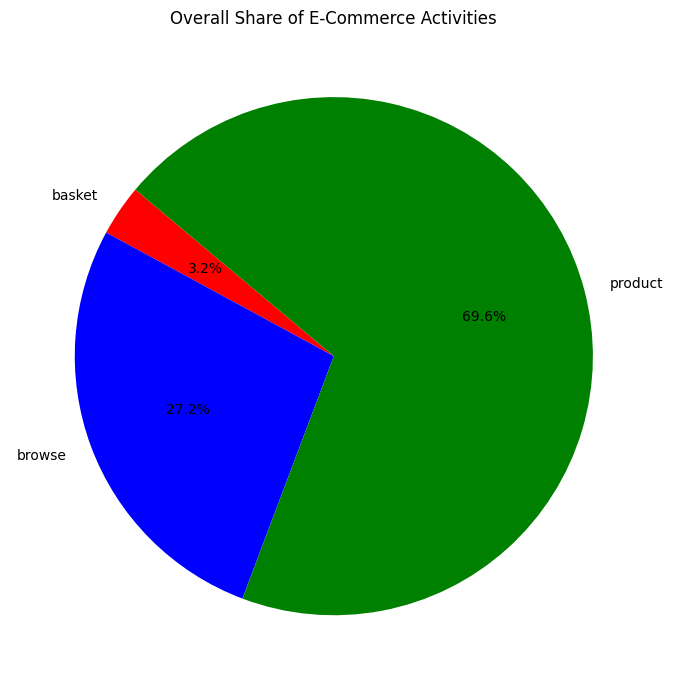

In [11]:
# Total count of each event
totals = df.groupby('event').size()

plt.figure(figsize=(7, 7))
plt.pie(
    totals,
    labels=totals.index,
    autopct='%1.1f%%',
    colors=['red', 'blue', 'green'],
    startangle=140
)
plt.title('Overall Share of E-Commerce Activities')
plt.tight_layout()
plt.show()

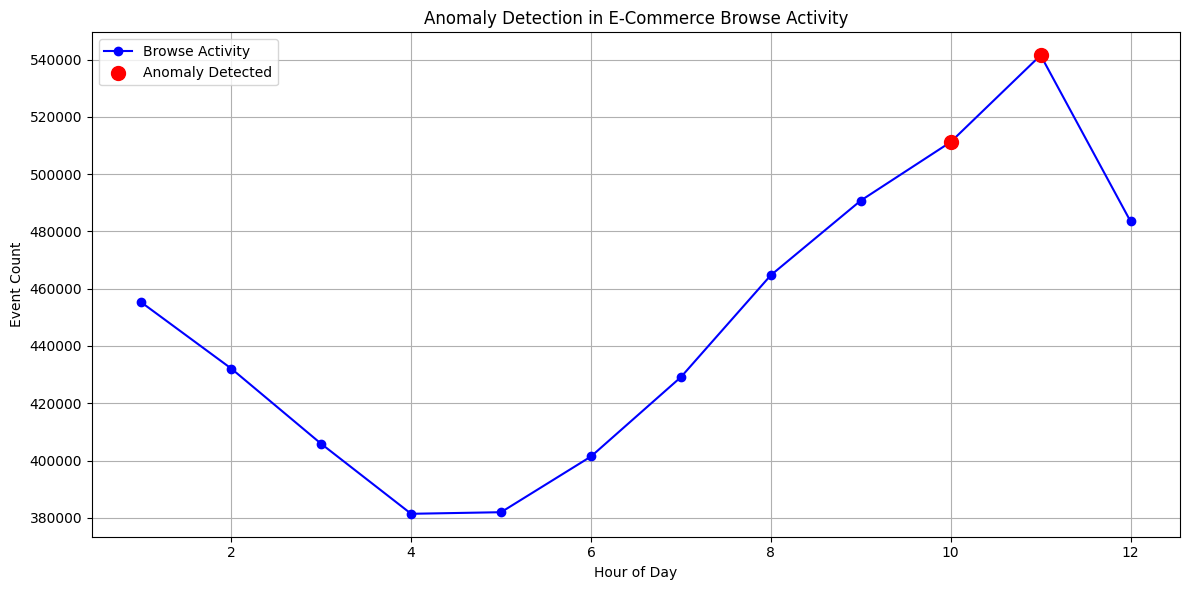


Anomalous Hours Detected:
    hour   count
28    10  511244
31    11  541543


In [12]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Use browse hourly counts for anomaly detection
browse_counts = browse_data['count'].values.reshape(-1, 1)

# Train Isolation Forest model
model = IsolationForest(contamination=0.1, random_state=42)
model.fit(browse_counts)

# Predict anomalies (-1 = anomaly, 1 = normal)
browse_data = browse_data.copy()
browse_data['anomaly'] = model.predict(browse_counts)

# Plot anomalies on line chart
plt.figure(figsize=(12, 6))
plt.plot(browse_data['hour'], browse_data['count'], marker='o', color='blue', label='Browse Activity')

# Highlight anomalies in red
anomalies = browse_data[browse_data['anomaly'] == -1]
plt.scatter(anomalies['hour'], anomalies['count'], color='red', s=100, zorder=5, label='Anomaly Detected')

plt.title('Anomaly Detection in E-Commerce Browse Activity')
plt.xlabel('Hour of Day')
plt.ylabel('Event Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nAnomalous Hours Detected:")
print(anomalies[['hour', 'count']])

In [14]:
print("=" * 50)
print("   E-COMMERCE LOG ANALYSIS SUMMARY REPORT")
print("=" * 50)

print(f"\nTotal Browse Events   : {browse_data['count'].sum():,}")
print(f"Total Product Events  : {product_data['count'].sum():,}")
print(f"Total Basket Events   : {basket_data['count'].sum():,}")

print(f"\nPeak Browse Hour      : {browse_data.loc[browse_data['count'].idxmax(), 'hour']} AM/PM")
print(f"Peak Product Hour     : {product_data.loc[product_data['count'].idxmax(), 'hour']} AM/PM")
print(f"Peak Basket Hour      : {basket_data.loc[basket_data['count'].idxmax(), 'hour']} AM/PM")

anomaly_hours = [int(h) for h in anomalies['hour'].values]
print(f"Anomaly Hours Detected: {anomaly_hours}")
print(f"Conversion Rate       : {round((basket_data['count'].sum() / browse_data['count'].sum()) * 100, 2)}%")

print("\n" + "=" * 50)
print("        Analysis Complete!")
print("=" * 50)

   E-COMMERCE LOG ANALYSIS SUMMARY REPORT

Total Browse Events   : 5,378,843
Total Product Events  : 13,779,768
Total Basket Events   : 632,326

Peak Browse Hour      : 11 AM/PM
Peak Product Hour     : 6 AM/PM
Peak Basket Hour      : 11 AM/PM
Anomaly Hours Detected: [10, 11]
Conversion Rate       : 11.76%

        Analysis Complete!
